# Chapter 3 experiment harness

Reproduces the results chapter 3 reports: figures 3.3, 3.4, 3.5, 3.6, 3.7 and 3.8, and
tables 3.4, 3.5, 3.6, 3.8, 3.10 and 3.11, plus the replay experiment of section 3.4.6.

One dataset throughout: 19,965 observations held by sixteen workers in unequal
batches, true mean 11.9818. The all-participant reduction requires all sixteen.
Commit-and-merge requires a completion quorum of twelve and keeps collecting until
the collection window or the deadline closes the epoch.

Nothing is reimplemented here. The kernels and the protocol are the chapter's own
modules; `epoch_experiments.py` drives them with seeded arrivals and dropout, and
this notebook only runs it and draws the figures.

## Environment

In [1]:
import math
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np

import epoch_experiments as ex
import partial_launcher
from population import make_population

REPS = 20              # arrival seeds per cell; 20 x 60 epochs = 1,200 epochs a cell

print("CUDA kernel path live:", partial_launcher.gpu_available())
print("evidence class       : simulated_decentralized")
print("  the arithmetic is real; arrival times, dropout and the network are seeded draws")

INK, ACCENT, WARN, GREEN = "#1b1b1b", "#0b6fa4", "#b3452c", "#6b8f3a"
TAILS = [(0.1, ACCENT, "tight"), (0.5, GREEN, "moderate"), (1.2, WARN, "severe")]


def clean(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

CUDA kernel path live: True
evidence class       : simulated_decentralized
  the arithmetic is real; arrival times, dropout and the network are seeded draws


## 3.1 The mean reduction kernels

`meanreductionkernel.cu` holds both kernels. Listing 3.2 finalizes the mean inside
the block. Here it runs on the sixteen values of figure 3.2.

In [2]:
v = np.arange(16, dtype=np.float32)
print(f"MeanReductionKernel, one block of 16 : {partial_launcher.mean_kernel(v):.4f}")
print(f"NumPy                                : {v.mean():.4f}")

MeanReductionKernel, one block of 16 : 7.5000
NumPy                                : 7.5000


Listing 3.3 returns `(sum, count)` instead and never divides. `partial_launcher`
(listing 3.4) cuts a worker's shard into power-of-two blocks of at most 1,024,
reduces each one, and merges the block partials into one worker contribution.

In [3]:
pop = make_population(seed=0)


def kernel_reduce(values):
    """A worker's contribution, computed by listing 3.4 on the kernel of listing 3.3."""
    s, c = partial_launcher.partial_launcher(0, values)
    return float(s.get()[0]), int(c.get()[0])


def blocks(n):
    out = []
    while n > 0:
        b = min(1024, 1 << (n.bit_length() - 1))
        out.append(b)
        n -= b
    return out


w = max(pop.workers, key=lambda w: w.record_count)
s, c = kernel_reduce(pop.records[w.worker_id])
exact = pop.partial(w.worker_id)
print(f"worker {w.worker_id}: {c:,} records, reduced as blocks of {blocks(c)}")
print(f"  kernel (float32)  : sum {s:,.4f}  count {c}")
print(f"  host   (float64)  : sum {exact[0]:,.4f}  count {exact[1]}")

worker 9: 2,387 records, reduced as blocks of [1024, 1024, 256, 64, 16, 2, 1]
  kernel (float32)  : sum 28,774.2090  count 2387
  host   (float64)  : sum 28,774.2110  count 2387


## 3.2 The working example

Sixteen workers, unequal batches. Every experiment below uses these workers, with
each worker's `(sum, count)` computed by the kernel above.

In [4]:
counts = [w.record_count for w in pop.workers]
print(f"workers          : {len(counts)}")
print(f"records          : {sum(counts):,}  (per worker {min(counts):,} to {max(counts):,})")
print(f"true mean        : {pop.exact_mean():.4f}")
print(f"population SD    : {np.std(pop.all_values()):.4f}")

workers          : 16
records          : 19,965  (per worker 369 to 2,387)
true mean        : 11.9818
population SD    : 3.0432


## Figure 3.3

The three arrival-tail settings. Completion times are lognormal with a log-mean of
zero, so all three share a median of 1.0. The dots are each setting's mean; the
dotted lines are the median of the slowest of sixteen workers.

tight     mean 1.01   slowest of 16 1.19
moderate  mean 1.13   slowest of 16 2.37
severe    mean 2.05   slowest of 16 7.91


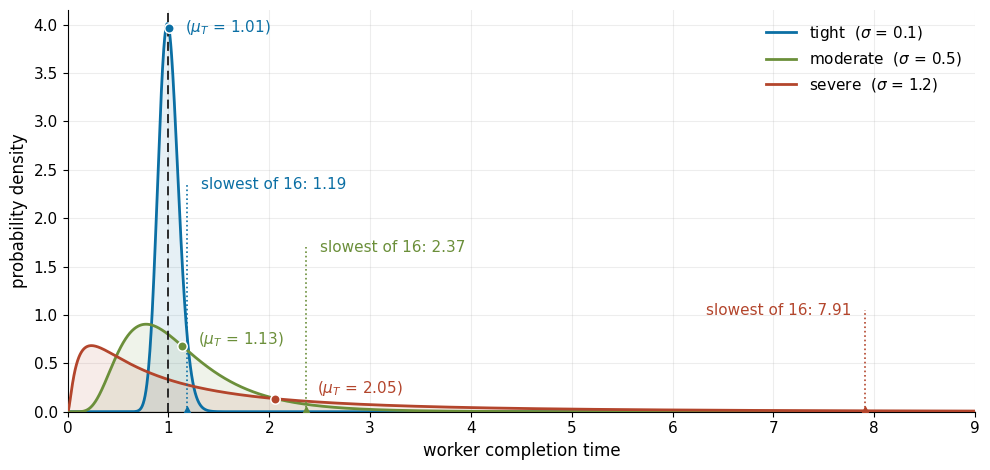

In [5]:
x = np.linspace(0.01, 9.0, 3000)
z = NormalDist().inv_cdf(0.5 ** (1.0 / 16))          # median of the max of 16


def density(t, sg):
    return np.exp(-(np.log(t) ** 2) / (2 * sg * sg)) / (t * sg * math.sqrt(2 * math.pi))


mean_offsets = {0.1: (0.16, 0.00), 0.5: (0.16, 0.06), 1.2: (0.42, 0.10)}
label_heights = {0.1: 2.35, 0.5: 1.70, 1.2: 1.05}

fig, ax = plt.subplots(figsize=(10, 4.8))
for sg, col, name in TAILS:
    ax.plot(x, density(x, sg), color=col, lw=2.0, label=f"{name}  ($\\sigma$ = {sg})", zorder=3)
    ax.fill_between(x, 0, density(x, sg), color=col, alpha=0.10, zorder=2)

    m = math.exp(sg * sg / 2)                          # the mean worker, marked and labelled
    ax.scatter([m], [density(m, sg)], s=46, color=col, zorder=6, edgecolor="white", lw=1.1)
    dx, dy = mean_offsets[sg]
    ax.text(m + dx, density(m, sg) + dy, f"($\\mu_T$ = {m:.2f})", fontsize=11,
            color=col, va="center", ha="left", zorder=7)

    slowest = math.exp(sg * z)                         # what waiting for all 16 pays
    h = label_heights[sg]
    ax.plot([slowest, slowest], [0, h], color=col, lw=1.2, ls=":", zorder=4)
    ax.scatter([slowest], [0], marker="^", s=62, color=col, zorder=6)
    side = "right" if slowest > 6 else "left"
    ax.text(slowest + (-0.14 if side == "right" else 0.14), h, f"slowest of 16: {slowest:.2f}",
            fontsize=11, color=col, va="center", ha=side)
    print(f"{name:8}  mean {m:.2f}   slowest of 16 {slowest:.2f}")
ax.axvline(1.0, color=INK, lw=1.3, ls=(0, (5, 3)), zorder=4)
ax.set_xlim(0, 9)
ax.set_ylim(0, 4.15)
ax.set_xlabel("worker completion time", fontsize=12)
ax.set_ylabel("probability density", fontsize=12)
ax.legend(fontsize=11, frameon=False, loc="upper right")
ax.tick_params(labelsize=11)
ax.grid(alpha=0.22)
clean(ax)
fig.tight_layout()
plt.show()

## 3.2.3 Tables 3.4 and 3.5

The three experiments of table 3.3, 1,200 epochs each. Commit-and-merge uses
`k` = 12 and `α` = 1.5. The all-participant reduction is the listing 3.5
coordinator: it has no deadline, completes only when every worker is present, and
then pays the slowest of them.

In [6]:
head = ex.headline(reps=REPS, reduce=kernel_reduce)

print("Table 3.4 Synchronization behavior")
print(f"{'experiment':20}{'AP completion':>15}{'C&M completion':>16}"
      f"{'AP p99 close':>14}{'C&M p99 close':>15}")
for r in head:
    print(f"{r['experiment']:20}{r['ap_completion']:15.3f}{r['cm_completion']:16.3f}"
          f"{r['ap_close_p99']:14.2f}{r['cm_close_p99']:15.2f}")

print("\nTable 3.5 Commit-and-merge result quality")
print(f"{'experiment':20}{'merged (of 16)':>16}{'mean committed':>16}"
      f"{'5th to 95th percentile':>26}")
for r in head:
    lo, hi = r["cm_mean_p05"], r["cm_mean_p95"]
    spread = f"{lo:.4f}" if round(lo, 4) == round(hi, 4) else f"{lo:.4f} to {hi:.4f}"
    print(f"{r['experiment']:20}{r['cm_operands']:16.2f}{r['cm_mean']:16.4f}{spread:>26}")

Table 3.4 Synchronization behavior
experiment            AP completion  C&M completion  AP p99 close  C&M p99 close
healthy overhead              1.000           1.000          1.37           1.39
dropout sweep                 0.190           0.985          1.37           2.00
latency-tail sweep            1.000           1.000         43.82           7.65

Table 3.5 Commit-and-merge result quality
experiment            merged (of 16)  mean committed    5th to 95th percentile
healthy overhead               16.00         11.9818                   11.9818
dropout sweep                  14.48         11.9842        11.8415 to 12.0645
latency-tail sweep             13.42         11.9762        11.8041 to 12.0929


## Table 3.6 and figure 3.4

Separating the completion quorum from the deadline, as dropout rises. Arrival tail
0.1, deadline 2.0. The all-participant column is its own seeded run, so it differs
slightly from table 3.4's 0.190 at 10 percent dropout; the analytic value is
`(1 - 0.10)^16` = 0.185.

Table 3.6 Fraction of epochs committed
 dropout  all-participant, k=16   C&M, k=16   C&M, k=12
    0.00                  1.000       1.000       1.000
    0.05                  0.422       0.431       1.000
    0.10                  0.180       0.196       0.985
    0.20                  0.029       0.027       0.786
    0.30                  0.003       0.005       0.458


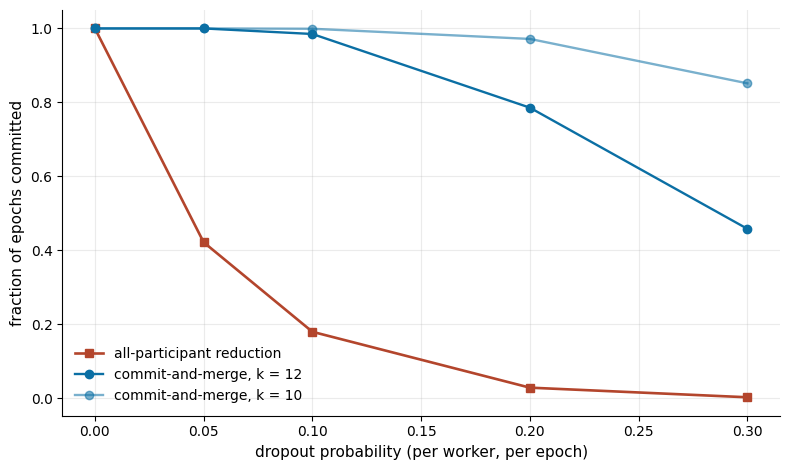

In [7]:
drop = ex.dropout_sweep(reps=REPS, reduce=kernel_reduce)

print("Table 3.6 Fraction of epochs committed")
print(f"{'dropout':>8}{'all-participant, k=16':>23}{'C&M, k=16':>12}{'C&M, k=12':>12}")
for r in drop:
    print(f"{r['dropout']:8.2f}{r['all_participant']:23.3f}{r[16]:12.3f}{r[12]:12.3f}")

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ps = [r["dropout"] for r in drop]
ax.plot(ps, [r["all_participant"] for r in drop], marker="s", color=WARN, lw=1.9,
        label="all-participant reduction")
for k, shade in ((12, 1.0), (10, 0.55)):
    ax.plot(ps, [r[k] for r in drop], marker="o", color=ACCENT, lw=1.7, alpha=shade,
            label=f"commit-and-merge, k = {k}")
ax.set_xlabel("dropout probability (per worker, per epoch)", fontsize=11)
ax.set_ylabel("fraction of epochs committed", fontsize=11)
ax.legend(fontsize=10, frameon=False)
ax.grid(alpha=0.25)
clean(ax)
fig.tight_layout()
plt.show()

## Figure 3.5

The p99 close time against arrival-tail severity, with no dropout and a deadline of
8.0. Commit-and-merge is `k` = 12, `α` = 1.5; each point averages the p99 of twenty
60-epoch runs. The all-participant curve is the p99 of the slowest of sixteen
workers over 4,000 seeded rounds. Both are separate samples from table 3.4, which
pools 1,200 epochs, so the points at `σ` = 1.2 differ from the table's 43.82 and 7.65.

sigma 0.1   all-participant p99   1.37   commit-and-merge p99  1.35
sigma 0.3   all-participant p99   2.66   commit-and-merge p99  2.06
sigma 0.5   all-participant p99   5.04   commit-and-merge p99  2.73
sigma 0.8   all-participant p99  13.13   commit-and-merge p99  4.11
sigma 1.2   all-participant p99  46.34   commit-and-merge p99  6.75


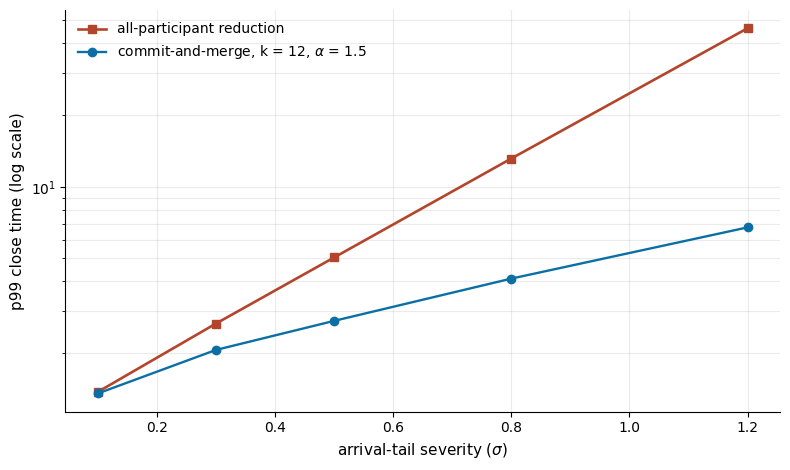

In [8]:
window = ex.window_sweep(reps=REPS, reduce=kernel_reduce)
tail = ex.tail_sweep(window)

for sg, a, c in zip(tail["sigma"], tail["all_participant"], tail["commit_and_merge"]):
    print(f"sigma {sg:3.1f}   all-participant p99 {a:6.2f}   commit-and-merge p99 {c:5.2f}")

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(tail["sigma"], tail["all_participant"], marker="s", color=WARN, lw=1.9,
        label="all-participant reduction")
ax.plot(tail["sigma"], tail["commit_and_merge"], marker="o", color=ACCENT, lw=1.7,
        label=r"commit-and-merge, k = 12, $\alpha$ = 1.5")
ax.set_yscale("log")
ax.set_xlabel(r"arrival-tail severity ($\sigma$)", fontsize=11)
ax.set_ylabel("p99 close time (log scale)", fontsize=11)
ax.legend(fontsize=10, frameon=False)
ax.grid(alpha=0.25, which="both")
clean(ax)
fig.tight_layout()
plt.show()

## 3.4.4 Figure 3.6

One work window, replayed through the protocol itself. Six eligible workers, a
completion quorum of `k` = 3, collection factor 1.5 and a deadline of 3.0. The
seven arrivals below are the ones in the figure; every colour is the status
`CommitMergeEpoch.receive()` recorded for that arrival, and the missing worker is
the one `freeze()` derived. Nothing in the picture is hand-labelled.


quorum time t_k : 1.7
closed          : COLLECTION at 2.55
manifest        : workers [0, 1, 2, 3]
missing         : workers [4]


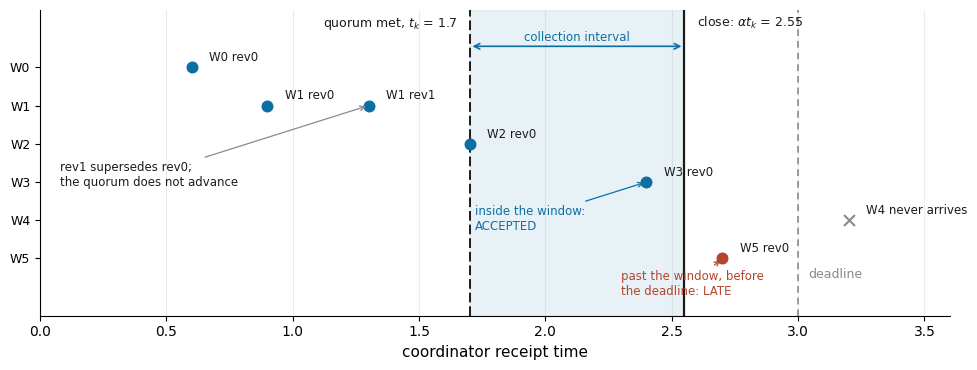

In [9]:
import commit_merge as cm

arrivals = [(0, 0, 0.6), (1, 0, 0.9), (1, 1, 1.3), (2, 0, 1.7),     # (worker, revision, time)
            (3, 0, 2.4), (5, 0, 2.7)]                               # worker 4 never arrives
cfg = cm.EpochConfig(epoch_id=0, eligible_workers=tuple(range(6)), base_state_id="s0",
                     op_id="mean", schema_id="sumcount.v1", k=3, alpha=1.5, deadline=3.0,
                     record_counts={w: 1 for w in range(6)},
                     merge_profile_id="sorted-by-worker-f64-intcount")
epoch = cm.CommitMergeEpoch(cfg)

events = []
for w, rev, t in arrivals:
    epoch.receive(cm.Contribution(epoch_id=0, worker_id=w, revision=rev, base_state_id="s0",
                                  partial_sum=float(w + rev), partial_count=1), t)
    events.append((w, t, f"W{w} rev{rev}", epoch.acks[-1].status))
manifest = epoch.freeze()
missing = [a.worker_id for a in epoch.acks if a.status is cm.Status.MISSING]

print(f"quorum time t_k : {epoch.t_k}")
print(f"closed          : {epoch.close_reason.name} at {epoch.close_time:.2f}")
print(f"manifest        : workers {[e.worker_id for e in manifest]}")
print(f"missing         : workers {missing}")

MUTED = "#8a8a8a"
colors = {cm.Status.ACCEPTED: ACCENT, cm.Status.LATE: WARN}
n, t_k, close_t = 6, epoch.t_k, epoch.close_time

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.axvspan(t_k, close_t, color=ACCENT, alpha=0.09, zorder=0)
for w, t, label, status in events:
    y = (n - 1) - w
    ax.scatter([t], [y], s=58, color=colors[status], zorder=3)
    ax.text(t + 0.07, y + 0.16, label, fontsize=8.5, color=INK)
for w in missing:
    y = (n - 1) - w
    ax.scatter([3.2], [y], marker="x", s=62, color=MUTED, zorder=3)
    ax.text(3.2 + 0.07, y + 0.16, f"W{w} never arrives", fontsize=8.5, color=INK)

ax.axvline(t_k, color=INK, lw=1.4, ls=(0, (5, 2)))
ax.text(t_k - 0.05, n + 0.05, f"quorum met, $t_k$ = {t_k:g}", fontsize=9, color=INK, ha="right")
ax.axvline(close_t, color=INK, lw=1.6)
ax.text(close_t + 0.05, n + 0.05, rf"close: $\alpha t_k$ = {close_t:.2f}", fontsize=9, color=INK)
ax.axvline(cfg.deadline, color=MUTED, lw=1.2, ls=(0, (4, 3)))
ax.text(cfg.deadline + 0.04, -0.5, "deadline", fontsize=9, color=MUTED)
ax.annotate("", xy=(close_t, n - 0.45), xytext=(t_k, n - 0.45),
            arrowprops=dict(arrowstyle="<->", color=ACCENT, lw=1.2))
ax.text((t_k + close_t) / 2, n - 0.30, "collection interval", fontsize=8.5, color=ACCENT, ha="center")

ax.annotate("rev1 supersedes rev0;\nthe quorum does not advance", xy=(1.3, 4), xytext=(0.08, 1.9),
            fontsize=8.5, color=INK, arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.9))
ax.annotate("inside the window:\nACCEPTED", xy=(2.4, 2), xytext=(1.72, 0.75),
            fontsize=8.5, color=ACCENT, arrowprops=dict(arrowstyle="->", color=ACCENT, lw=0.9))
ax.annotate("past the window, before\nthe deadline: LATE", xy=(2.7, 0), xytext=(2.30, -0.95),
            fontsize=8.5, color=WARN, arrowprops=dict(arrowstyle="->", color=WARN, lw=0.9))

ax.set_yticks(range(n))
ax.set_yticklabels([f"W{i}" for i in range(n - 1, -1, -1)], fontsize=9)
ax.set_xlabel("coordinator receipt time", fontsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.set_xlim(0, 3.6)
ax.set_ylim(-1.5, n + 0.5)
ax.grid(axis="x", alpha=0.25)
clean(ax)
fig.tight_layout()
plt.show()

## Table 3.8

The collection window. `k` = 12, no dropout, deadline 8.0, 1,200 epochs per cell.
Fleet speed multiplies every worker's completion time; the arrival tail changes
the shape of the distribution instead.

In [10]:
print("Table 3.8 Collection window analysis")
print(f"{'fleet speed':>12}{'arrival tail':>15}{'alpha':>7}{'mean merged':>13}{'P50 close':>11}")
for scale, sg, al in [(1.0, 0.1, 1.0), (1.0, 0.1, 1.5), (1.0, 1.2, 1.0), (1.0, 1.2, 1.5),
                      (1.0, 1.2, 2.0), (2.0, 0.1, 1.5), (2.0, 1.2, 1.5)]:
    cell = window[(scale, sg, al)]
    name = "tight, 0.1" if sg == 0.1 else "severe, 1.2"
    print(f"{scale:11.0f}x{name:>15}{al:7.2f}{cell['operands']:13.2f}{cell['close_p50']:11.2f}")

Table 3.8 Collection window analysis
 fleet speed   arrival tail  alpha  mean merged  P50 close
          1x     tight, 0.1   1.00        12.00       1.06
          1x     tight, 0.1   1.50        16.00       1.19
          1x    severe, 1.2   1.00        12.00       1.99
          1x    severe, 1.2   1.50        13.42       2.98
          1x    severe, 1.2   2.00        14.22       3.91
          2x     tight, 0.1   1.50        16.00       2.37
          2x    severe, 1.2   1.50        13.27       5.97


## Figures 3.7 and 3.8

What the collection window collects, and the error the remaining contributions
leave behind. Deviation is the mean absolute distance of the committed mean from
11.9818, in population standard deviations, over committed epochs.

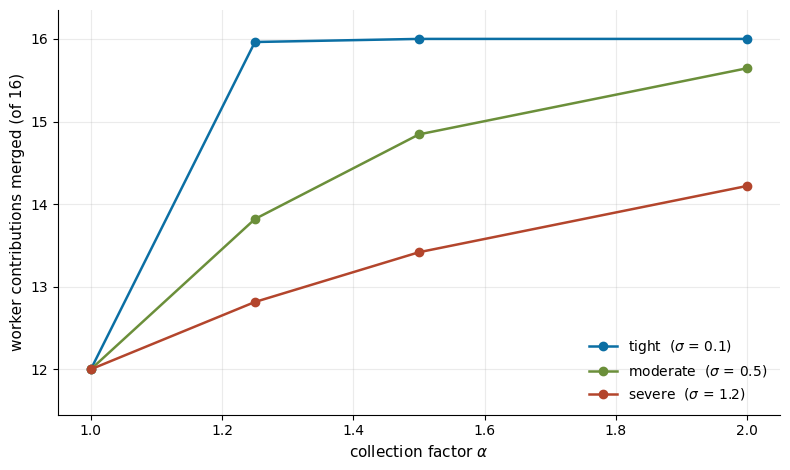

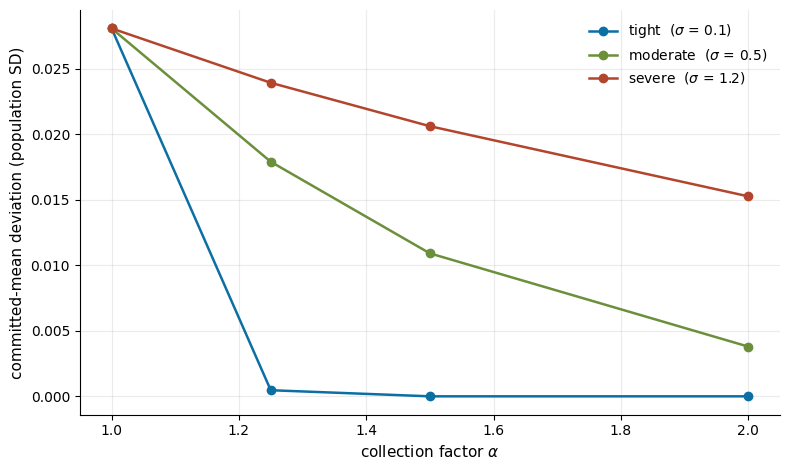

In [11]:
for number, key, ylabel in (("3.7", "operands", "worker contributions merged (of 16)"),
                            ("3.8", "mean_deviation_norm",
                             "committed-mean deviation (population SD)")):
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    for sg, col, name in TAILS:
        ax.plot(ex.ALPHAS, [window[(1.0, sg, al)][key] for al in ex.ALPHAS], marker="o",
                color=col, lw=1.8, label=f"{name}  ($\\sigma$ = {sg})")
    ax.set_xlabel(r"collection factor $\alpha$", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if key == "operands":
        ax.set_ylim(11.45, 16.35)
        ax.legend(fontsize=10, frameon=False, loc="lower right")
    else:
        ax.legend(fontsize=10, frameon=False)
    ax.grid(alpha=0.25)
    clean(ax)
    fig.tight_layout()
    plt.show()

## 3.4.6 Replay determinism

One frozen manifest of sixteen contributions, merged 200 times with its arrival
order shuffled. `canonical_merge` (listing 3.13) accumulates in worker-ID order in
float64; the other two accumulate in arrival order.

In [12]:
rep = ex.replay_determinism()
print(f"distinct committed results over {rep['trials']} shuffled replays")
print(f"  canonical order, float64    : {rep['canonical_f64']}")
print(f"  arrival order,   float64    : {rep['arrival_order_f64']}")
print(f"  arrival order,   float32    : {rep['arrival_order_f32']}")

distinct committed results over 200 shuffled replays
  canonical order, float64    : 1
  arrival order,   float64    : 4
  arrival order,   float32    : 4


## 3.4.8 Table 3.10

Each condition is injected into a fresh epoch once, and the state it lands in is
read back from the epoch's own acknowledgements.

In [13]:
print(f"{'injected condition':38}{'recorded state':38}{'reason'}")
for r in ex.contribution_state_checks():
    print(f"{r['condition']:38}{r['state']:38}{r['reason']}")

injected condition                    recorded state                        reason
Exact retransmission                  DUPLICATE                             already_processed
Same revision, different payload      REJECTED                              revision_payload_conflict
Higher valid revision                 ACCEPTED, prior candidate SUPERSEDED  ok
Stale revision                        REJECTED                              stale_revision
Ineligible worker                     REJECTED                              not_a_member
Non-integer count                     REJECTED                              count_not_an_integer
Malformed count                       REJECTED                              count_not_positive
Count disagrees with the declaration  REJECTED                              count_mismatch
Wrong epoch                           REJECTED                              wrong_epoch
Wrong base state                      REJECTED                              wrong_base_stat

## 3.5.1 Table 3.11

Partial participation at the same twelve-worker quorum. Here the collection factor
is 1.0, so every committed manifest is exactly the quorum. In the correlated case
the slow half of the workers is 2.5 times slower and also holds higher values.

In [14]:
print(f"{'worker availability':30}{'record coverage':>17}{'mean deviation, SD':>20}"
      f"{'empirical bias, SD':>20}")
for r in ex.availability(reps=REPS, reduce=kernel_reduce):
    name = "correlated with worker data" if r["correlated"] else "independent of worker data"
    print(f"{name:30}{r['record_coverage']:17.3f}{r['mean_deviation_norm']:20.4f}"
          f"{r['mean_bias_norm']:20.4f}")

worker availability             record coverage  mean deviation, SD  empirical bias, SD


independent of worker data                0.750              0.0281              0.0037
correlated with worker data               0.744              0.0850              0.0850


## 3.5.2 A declared sample's liveness

A declared sample must wait for every sampled worker, so with independent dropout
`p` it commits with probability `(1 - p)^s`.

In [15]:
print(f"s = 8 sampled workers at 10 percent dropout: (1 - 0.10)^8 = {(1 - 0.10) ** 8:.2f}")

s = 8 sampled workers at 10 percent dropout: (1 - 0.10)^8 = 0.43


## What the harness does not show

**The network.** Workers are seeded arrival times, not machines. Every close time
is in units of the median worker's completion time, and every dropout is a coin
flip per worker per epoch. That is what `simulated_decentralized` means.

**Wall-clock coordination.** `commit_merge_coordinator.py` runs listing 3.15 for
real, with threads as workers and the wall clock as time:
`python commit_merge_coordinator.py`. Listings 3.5 and 3.6 run the same way from
`distributed_mean_coordinator.py` and `all_reduce_coordinator.py`.

**Representativeness.** Table 3.11 holds everything fixed except whether slow
workers hold different data. A real deployment does not get to choose, which is
why section 3.5.2 separates an arrival quorum from a declared sample.